### Support Vector Classifier (SVC) Modeling

The cleaned dataset from exploratory data analysis is loaded.

The features and target variable are defined and split into train and test sets.

Features are scaled and encoded as required during preprocessing.

The parameter **class_weight** addresses the class imbalance.

A pipeline is used and model parameters are optimized using **HalvingRandomSearchCV**.     

**Classification report** and **confusion matrix** verify the accuracy, precision, and recall as well as display the **true negatives**, **false positives**, **false negatives**, and **true positives**.   

**Costs** and **savings** are defined to support the **profit_loss_analysis**.   

The **thresholds** are tuned to optimize the profits.  
    
**Feature importance** is ranked and further analyzed using **SHAP**.    

The model **performance metrics**, **feature importances**, and **SHAP** importances are output and compared with other models in a models summary notebook.

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.     


**Import the required libraries**

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [3]:
# Load the dataset
df = pd.read_csv('cleaned_data_ccp.csv')

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction',
 'avg_monthly_usage',
 'charge_increase',
 'is_new_customer',
 'is_loyal_customer',
 'activity_ratio',
 'usage_trend',
 'auto_payment',
 'negative_customer',
 'no_referrals',
 'has_referrals',
 'high_referral_customer',
 'high_escalations',
 'referral_tenure',
 'loyal_monthly_customer',
 'tickets_support',
 'is_happy_customer',
 'not_happy_customer',
 'high_fee_customer',
 'budget_customer',
 'high_risk_flags1',
 'high_risk_flags2',
 'high_risk_flags5',
 'high_risk_flags6',
 'high_risk_flags7',
 'high_risk_flags8',
 'high_risk_flags9',
 'high_risk_flags10',
 'high_risk_flags11',
 'high_risk_flags12',
 'high_risk_

In [7]:
# Define numeric_cols less the target variable 'churn'
numeric_cols = [col for col in numerical_columns if col != 'churn']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 117 numeric columns.


In [8]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'features_used',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response',
 'tenure_group']

In [9]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response','customer_segment']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 3 ordinal columns and 10 nominal columns.


In [10]:
# Verify 'contract_type', 'survey_response', and 'customer_segment'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts(), '\n')
print(df['customer_segment'].value_counts())

contract_type
Monthly      4967
Quarterly    3050
Yearly       1983
Name: count, dtype: int64 

survey_response
Satisfied      4975
Neutral        2978
Unsatisfied    2047
Name: count, dtype: int64 

customer_segment
Individual    5984
SME           3029
Enterprise     987
Name: count, dtype: int64


In [11]:
# Define ordinal categories
ordinal_categories=[
  ['Monthly','Quarterly','Yearly'],          # contract_type
  ['Unsatisfied','Neutral','Satisfied'],     # survey_response
  ['Individual','SME','Enterprise']          # customer_segment
]

In [12]:
# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop=None, handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [13]:
# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', SVC(probability=True, random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel'...
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction',
                                                   'avg_monthly_usage',
                                                   'charge_increase',
                                                   'is_new_customer',
                                                   'is_loyal_customer',
                                                   'activity_ratio',
                                                   'usage_trend',
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('svc', SVC(probability=True, random_state=42))])

In [14]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 90.60%
The test accuracy of the model is 89.70%


In [15]:
# Generate classification report
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.95      1796
           1       0.46      0.05      0.10       204

    accuracy                           0.90      2000
   macro avg       0.68      0.52      0.52      2000
weighted avg       0.86      0.90      0.86      2000



The model does not catch churners effectively (recall=0.05 for the positive class) and will be improved.

In [16]:
# Define parameter grid
param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.01, 0.1, 1, 10],
        'svc__class_weight': ['balanced']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svc__class_weight': ['balanced']
    }
]

In [17]:
# Run HalvingRandomSearchCV to find the optimum mix of parameters
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = HalvingRandomSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best score: {grid.best_score_:.4f}')

Best parameters: {'svc__kernel': 'rbf', 'svc__gamma': 'auto', 'svc__class_weight': 'balanced', 'svc__C': 1}
Best score: 0.2889


In [18]:
# Access the optimized xgb_pipe1 pipeline model
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied'],
                                                                             ['Individual',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['contract_type',
                                                   'survey_response',
                                                   'customer_segment']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'signup_channel'...
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction',
                                                   'avg_monthly_usage',
                                                   'charge_increase',
                                                   'is_new_customer',
                                                   'is_loyal_customer',
                                                   'activity_ratio',
                                                   'usage_trend',
                                                   'auto_payment',
                                                   'negative_customer',
                                                   'no_referrals',
                                                   'has_referrals',
                                                   'high_referral_customer', ...])])),
                ('svc',
                 SVC(C=1, class_weight='balanced', gamma='auto',
                     probability=True, random_state=42))])

In [19]:
# Accuracy of model on train and test data
best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 75.81%
The test accuracy of the model is 73.90%


In [20]:
# Generate classification report
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84      1796
           1       0.25      0.75      0.37       204

    accuracy                           0.74      2000
   macro avg       0.60      0.74      0.60      2000
weighted avg       0.89      0.74      0.79      2000



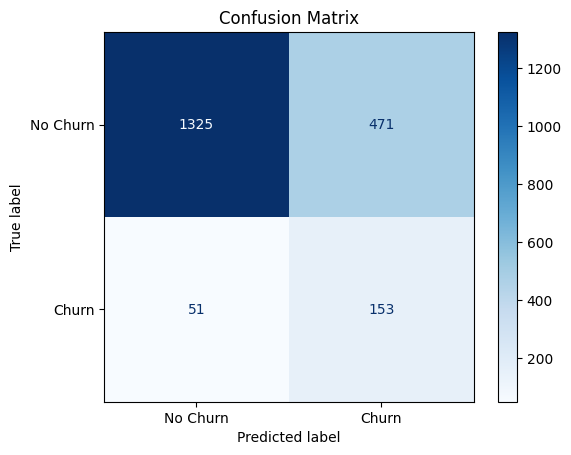

In [21]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [22]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 471 
 fn: 51 
 tp: 153 
 tn: 1325


In [23]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.74
Precision: 0.25
Recall: 0.75
---------------


In [24]:
# Calculate f2 score
beta = 2
f2_score = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.5313


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [25]:
# Profit/loss analysis
L=500
C=40
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $26,040


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

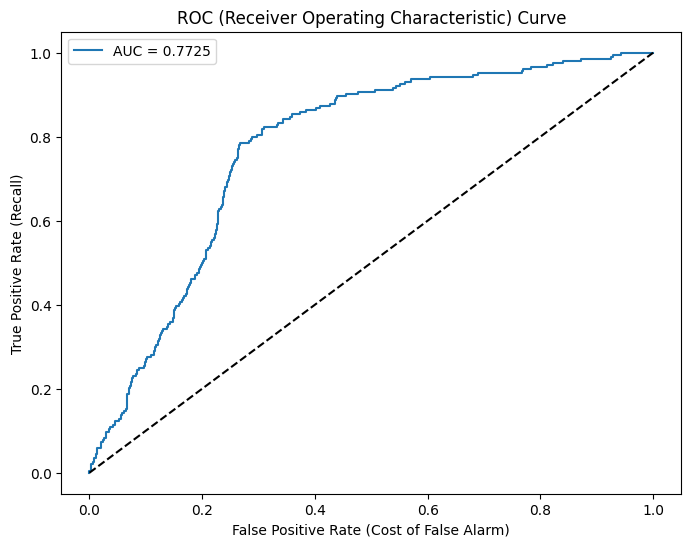

In [26]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 4)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.4f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [27]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold :.4f}')

The optimal threshold is 0.0862


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [28]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

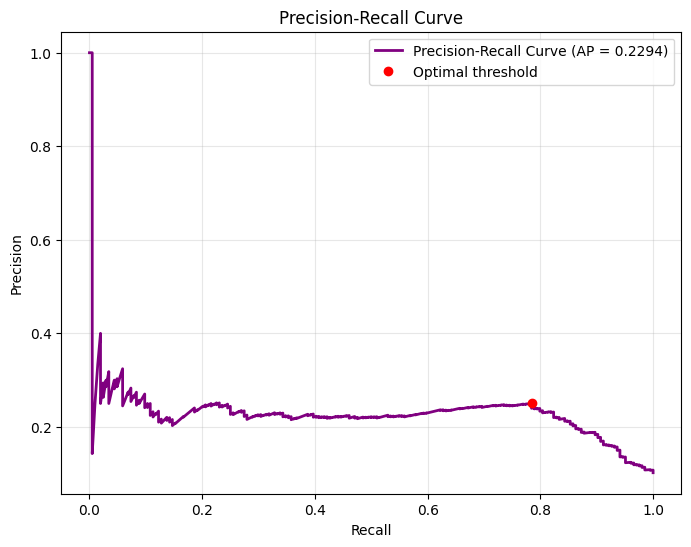

In [29]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.4f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [30]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.30, 0.01)
for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.10 | Recall=1.00
Threshold=0.01 | Precision=0.10 | Recall=1.00
Threshold=0.02 | Precision=0.10 | Recall=1.00
Threshold=0.03 | Precision=0.11 | Recall=1.00
Threshold=0.04 | Precision=0.16 | Recall=0.93
Threshold=0.05 | Precision=0.21 | Recall=0.85
Threshold=0.06 | Precision=0.23 | Recall=0.82
Threshold=0.07 | Precision=0.24 | Recall=0.78
Threshold=0.08 | Precision=0.25 | Recall=0.78
Threshold=0.09 | Precision=0.25 | Recall=0.78
Threshold=0.10 | Precision=0.25 | Recall=0.76
Threshold=0.11 | Precision=0.25 | Recall=0.75
Threshold=0.12 | Precision=0.25 | Recall=0.75
Threshold=0.13 | Precision=0.25 | Recall=0.75
Threshold=0.14 | Precision=0.25 | Recall=0.74
Threshold=0.15 | Precision=0.24 | Recall=0.72
Threshold=0.16 | Precision=0.24 | Recall=0.70
Threshold=0.17 | Precision=0.24 | Recall=0.68
Threshold=0.18 | Precision=0.24 | Recall=0.66
Threshold=0.19 | Precision=0.24 | Recall=0.63
Threshold=0.20 | Precision=0.23 | Recall=0.58
Threshold=0.21 | Precision=0.22 | 

In [31]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    profit_loss = tp*(L - C) - fp*C - fn*L
    profits.append(profit_loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.04


In [32]:
# Use the threshold that maximizes profit
y_pred = (y_probs >= best_threshold).astype(int)

In [33]:
# Generate classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.44      0.61      1796
           1       0.16      0.93      0.27       204

    accuracy                           0.49      2000
   macro avg       0.57      0.68      0.44      2000
weighted avg       0.90      0.49      0.57      2000



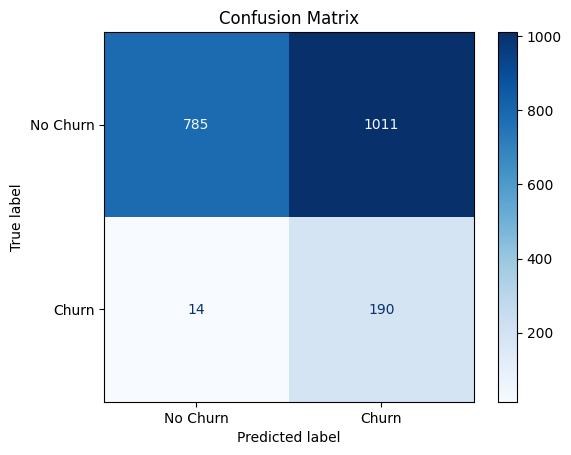

In [34]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [35]:
# Values for true negative (tn), false positive (fp), false negative (fn), and true positive (tp)
tn, fp, fn, tp = cm.ravel()

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn: {tn}')

 fp: 1011 
 fn: 14 
 tp: 190 
 tn: 785


In [36]:
# Calculations for accuracy, precision, recall
accuracy = round((tp + tn)/len(y_test), 4)
precision = round(tp/(tp + fp), 4)
recall = round(tp/(tp + fn), 4)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.49
Precision: 0.16
Recall: 0.93
---------------


In [37]:
# Calculate f2 score
beta = 2
f2_score = round((1 + beta**2) * (precision * recall) / (beta**2 * precision + recall), 4)

print(f'The f2 score is {f2_score:.4f}')

The f2 score is 0.4710


In [38]:
# Profit/loss analysis
profit_loss = tp*(L - C) - fp*C - fn*L

print(f'The profit or loss is ${profit_loss:,}')

The profit or loss is $39,960


**Feature Selection**      

Feature selection does not improve the model.

In [39]:
# Verify number of features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print(f'The number of transformed features is {len(feature_names)}.')

The number of transformed features is 157.


In [40]:
# Determine the best number of features
results = []
feature_counts = [90, 110, 130, 157]
# Transform
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

for k in feature_counts:
    # Selector
    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=k
    )
    # Feature selection
    X_train_selected = selector.fit_transform(
        X_train_trans,
        y_train
    )
    X_test_selected = selector.transform(
        X_test_trans
    )
    # Final model
    model = SVC(probability=True, random_state=42)
    model.fit(X_train_selected, y_train)
    # Predictions
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    # Metrics
    recall = recall_score(
        y_test,
        y_pred,
        average='macro'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    auc = roc_auc_score(y_test, y_proba)
    # Store results
    results.append({
        "num_features": k,
        "accuracy": accuracy,
        "recall": recall,
        "f1": f1,
        "auc": auc
    })
    # Selected features
    feature_names = preprocessor.get_feature_names_out()
    selected_features = feature_names[
      selector.get_support()
    ]

    print(f"\nTop {k} Features:")
    print(selected_features.tolist())

# Summary table
results_df = pd.DataFrame(results)

print("\nPerformance Summary:")
print(results_df)


Top 90 Features:
['ord__contract_type', 'ord__survey_response', 'nom__country_UK', 'nom__city_Sydney', 'nom__signup_channel_Mobile', 'nom__features_used_Few', 'nom__features_used_Many', 'nom__features_used_Medium', 'nom__discount_applied_No', 'nom__complaint_type_Service', 'nom__complaint_type_Technical', 'nom__tenure_group_(0, 4]', 'nom__tenure_group_(24, 36]', 'nom__tenure_group_(36, 52]', 'num__age', 'num__tenure_months', 'num__monthly_logins', 'num__weekly_active_days', 'num__avg_session_time', 'num__total_revenue', 'num__payment_failures', 'num__csat_score', 'num__escalations', 'num__marketing_click_rate', 'num__referral_count', 'num__tenure_fee_interaction', 'num__avg_monthly_usage', 'num__charge_increase', 'num__is_new_customer', 'num__is_loyal_customer', 'num__activity_ratio', 'num__usage_trend', 'num__auto_payment', 'num__no_referrals', 'num__has_referrals', 'num__high_referral_customer', 'num__referral_tenure', 'num__is_happy_customer', 'num__not_happy_customer', 'num__high_

**Feature Importance**     


In [41]:
# Transform X_train
X_train_encoded = best_model.named_steps['preprocessor'].transform(X_train)
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names

# Train a proxy tree model
proxy_tree = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
proxy_tree.fit(X_train_encoded, y_train)

# View importances
tree_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": proxy_tree.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print(tree_importance.head(10))

                feature  importance
0        monthly_logins    0.037952
1      avg_session_time    0.035416
2           usage_trend    0.035018
3   avg_resolution_time    0.034586
4             nps_score    0.033711
5         charge_shocks    0.033096
6         tenure_months    0.032944
7  marketing_click_rate    0.032612
8                   age    0.031963
9     usage_growth_rate    0.031458


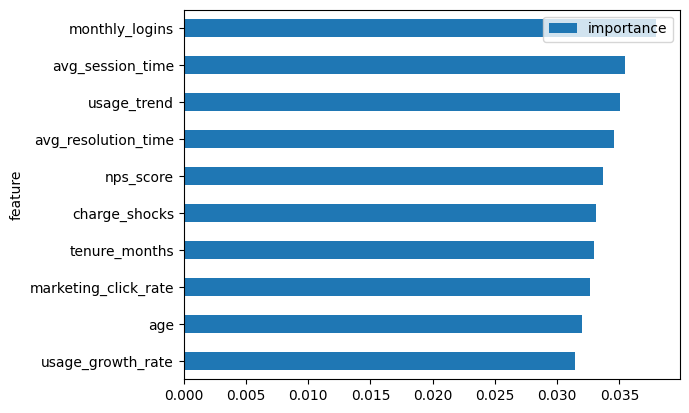

In [42]:
# Visualize
importance_df = tree_importance
importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh"
)
plt.gca().invert_yaxis()
plt.show()

**SHAP Analysis**     

Unhappy customers and those with low monthly logins churn.

Low csat_score churns.

Not happy customer with csat_score=2.0 churns.

Those with payment failures are likely to churn.

Those with total_revenue of less than 200 and tenure_months of less than 4 months are likely to churn.

PermutationExplainer explainer: 26it [01:34,  4.09s/it]


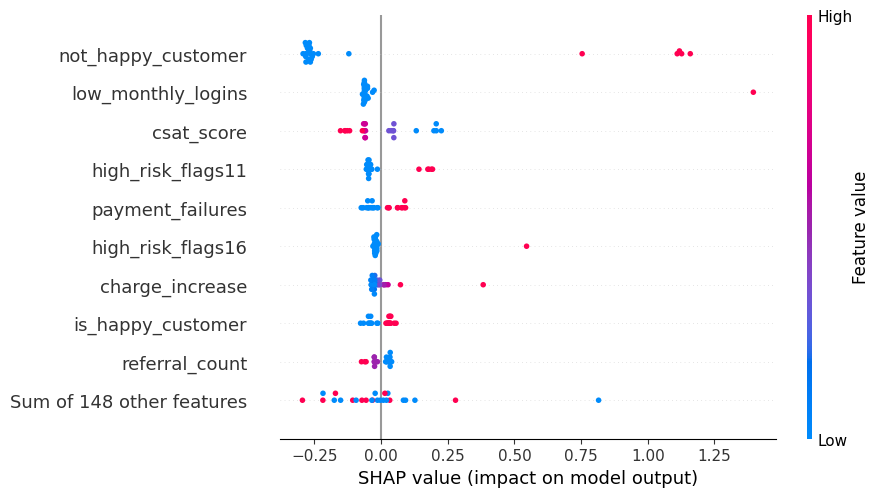

In [43]:
# Transform data for SHAP
X_train_encoded = best_model.named_steps['preprocessor'].transform(X_train)
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]  # Clean feature names
X_train_df = pd.DataFrame(X_train_encoded, columns=feature_names)

# Grab small samples to quicken calculations
fast_background = X_train_df.sample(25, random_state=42)
fast_test = X_train_df.sample(25, random_state=42)

# Use decision_function if SVC without probability=True
svc_step = best_model.named_steps['svc']
explainer = shap.Explainer(svc_step.decision_function, fast_background)
shap_values = explainer(fast_test)

# Plot the beeswarm
shap.plots.beeswarm(shap_values)

In [44]:
# Verify SHAP importance
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="importance", ascending=False)

print(shap_importance.head(30))

                      feature  importance
75         not_happy_customer    0.420719
151        low_monthly_logins    0.111243
52                 csat_score    0.097998
86          high_risk_flags11    0.070558
49           payment_failures    0.051102
91          high_risk_flags16    0.041192
60            charge_increase    0.038928
74          is_happy_customer    0.036802
57             referral_count    0.031154
38       tenure_group_(4, 24]    0.029139
156             charge_shocks    0.024286
42             monthly_logins    0.024051
51        avg_resolution_time    0.020593
46        last_login_days_ago    0.018796
153      high_charge_increase    0.018572
59          avg_monthly_usage    0.017901
41              tenure_months    0.016780
67               no_referrals    0.014999
68              has_referrals    0.014892
43         weekly_active_days    0.014822
8             country_Germany    0.013812
20    signup_channel_Referral    0.013284
45          usage_growth_rate    0

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.  

In [45]:
# Build dataframe
svc_model_df = pd.DataFrame({
    'Model': ['SVC'],
    'AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F2_Score': [f2_score],
    'Profit_Loss': [profit_loss],
})
svc_model_df

,Model,AUC,Accuracy,Precision,Recall,F2_Score,Profit_Loss
0,SVC,0.705222,0.897,0.1582,0.523342,0.471,39960


In [46]:
# Output model performance
svc_model_df.to_csv("svc_metrics.csv", index=False)

In [47]:
# Output the features importance
importance_df.to_csv("svc_features.csv", index=False)

In [48]:
# Output the SHAP importance
shap_importance.to_csv("svc_shap.csv", index=False)

**Sample Predictions**

In [49]:
# Obtain sample_1 from X_test
sample_1 = X_test.loc[[6563]]
proba_1 = best_model.predict_proba(sample_1)

print(f'The probabilities are {proba_1}')

The probabilities are [[0.95948741 0.04051259]]


In [50]:
# Verify actual churn

print("Actual churn:", y_test.loc[6563])

Actual churn: 1


In [51]:
# Predict a true positive
pred_1 = int(proba_1[:,1] >= best_threshold)

print("Predicted churn:", pred_1)

Predicted churn: 1


In [52]:
# Obtain sample_2 from X_test
sample_2 = X_test.loc[[4503]]
proba_2 = best_model.predict_proba(sample_2)

print(f'The probabilities are {proba_2}')

The probabilities are [[0.96284564 0.03715436]]


In [53]:
# Verify actual churn

print("Actual churn:", y_test.loc[4503])

Actual churn: 0


In [54]:
# Predict a true negative
pred_2 = int(proba_2[:,1] >= best_threshold)

print("Predicted churn:", pred_2)

Predicted churn: 0


In [55]:
# Obtain sample_3 from X_test
sample_3 = X_test.loc[[5978]]
proba_3 = best_model.predict_proba(sample_3)

print(f'The probabilities are {proba_3}')

The probabilities are [[0.95594211 0.04405789]]


In [56]:
# Verify actual churn

print("Actual churn:", y_test.loc[5978])

Actual churn: 1


In [57]:
# Predict a true positive
pred_3 = int(proba_3[:,1] >= best_threshold)

print("Predicted churn:", pred_3)

Predicted churn: 1
